In [1]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import sys, platform, os
import matplotlib
from matplotlib import pyplot as plt
import numpy as np
import camb
from camb import model, initialpower
print('Using CAMB %s installed at %s'%(camb.__version__,os.path.dirname(camb.__file__)))
# make sure the version and path is what you expect

Using CAMB 1.5.9 installed at /mnt/lustre/scratch/nlsas/home/csic/eoy/ioj/CMBFeatureNet/CAMB/camb


In [2]:
# Planck TT data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TT-full_R3.01.txt')
ls_Planck_TT = data_Planck[:, 0]
dl_Planck_TT = data_Planck[:, 1]
sdl_Planck_TT1 = data_Planck[:, 2]
sdl_Planck_TT2 = data_Planck[:, 3]
round_ls_Pl_TT = np.round(ls_Planck_TT)

# Planck TE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-TE-full_R3.01.txt')
ls_Planck_TE = data_Planck[:, 0]
dl_Planck_TE = data_Planck[:, 1]
sdl_Planck_TE1 = data_Planck[:, 2]
sdl_Planck_TE2 = data_Planck[:, 3]
round_ls_Pl_TE = np.round(ls_Planck_TE)

# Planck EE data
data_Planck = np.loadtxt('./experimental_data/COM_PowerSpect_CMB-EE-full_R3.01.txt')
ls_Planck_EE = data_Planck[:, 0]
dl_Planck_EE = data_Planck[:, 1]
sdl_Planck_EE1 = data_Planck[:, 2]
sdl_Planck_EE2 = data_Planck[:, 3]
round_ls_Pl_EE = np.round(ls_Planck_EE)

In [3]:
#Simmetrize error bars
sdl_Planck_TT = (sdl_Planck_TT1 + sdl_Planck_TT2)/2
sdl_Planck_TE = (sdl_Planck_TE1 + sdl_Planck_TE2)/2
sdl_Planck_EE = (sdl_Planck_EE1 + sdl_Planck_EE2)/2

In [4]:
#Create a function for converting the c_ls^TT to Dls (for plotting and comparing)
import math
def Dls(l,CTT):
    Dl = [l[i]*(l[i]+1)*CTT[i]/(2*math.pi) for i in range(len(l))]
    return Dl

#Create a function for converting Dls to the c_ls^TT (Cov_Matrix)
import math
def sCls(l,sDlTT):
    sClTT = [(2*math.pi)/l[i]*(l[i]+1)*sDlTT[i] for i in range(len(l))]
    return sClTT

In [ ]:
#Create covariance matrix with TT Planck errors:
cov_matr_cls_tt = np.diag(sdl_Planck_TT**2) #[micro K^2]^2

#TE Planck errors:
cov_matr_cls_te = np.diag(sdl_Planck_TE**2) #[micro K^2]^2

#EE Planck errors:
cov_matr_cls_ee = np.diag(sdl_Planck_EE**2) #[micro K^2]^2

In [16]:
import csv

params = camb.set_params(H0=67.5, ombh2=0.022, omch2=0.122, mnu=0.06, omk=0, tau=0.06,  
                    As=2e-9, ns=0.965, halofit_version='mead', lmax=2507)

results = camb.get_results(params)
powers = results.get_cmb_power_spectra(params, CMB_unit='muK')
totCL = powers['total']
unlensedCL = powers['unlensed_scalar']

with open('./simulated_data/ttcls_camb_noisy.csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerow(round_ls_Pl_TT)
    clstt = unlensedCL[:len(cov_matr_cls_tt),0]
    np.random.seed(314159) 
    clstt_noisy = np.random.multivariate_normal(clstt, cov_matr_cls_tt, 1)
    writer.writerow(clstt_noisy[0])
x.close()

with open('./simulated_data/tecls_camb_noisy.csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerow(round_ls_Pl_TE)
    clste = unlensedCL[:len(cov_matr_cls_te),3]
    np.random.seed(314159) 
    clste_noisy = np.random.multivariate_normal(clste, cov_matr_cls_te, 1)
    writer.writerow(clste_noisy[0])
x.close()

with open('./simulated_data/eecls_camb_noisy.csv', 'w') as x:
    writer = csv.writer(x, delimiter=',',quoting=csv.QUOTE_NONNUMERIC)
    writer.writerow(round_ls_Pl_EE)
    clsee = unlensedCL[:len(cov_matr_cls_ee),1]
    np.random.seed(314159) 
    clsee_noisy = np.random.multivariate_normal(clsee, cov_matr_cls_ee, 1)
    writer.writerow(clsee_noisy[0])
x.close()

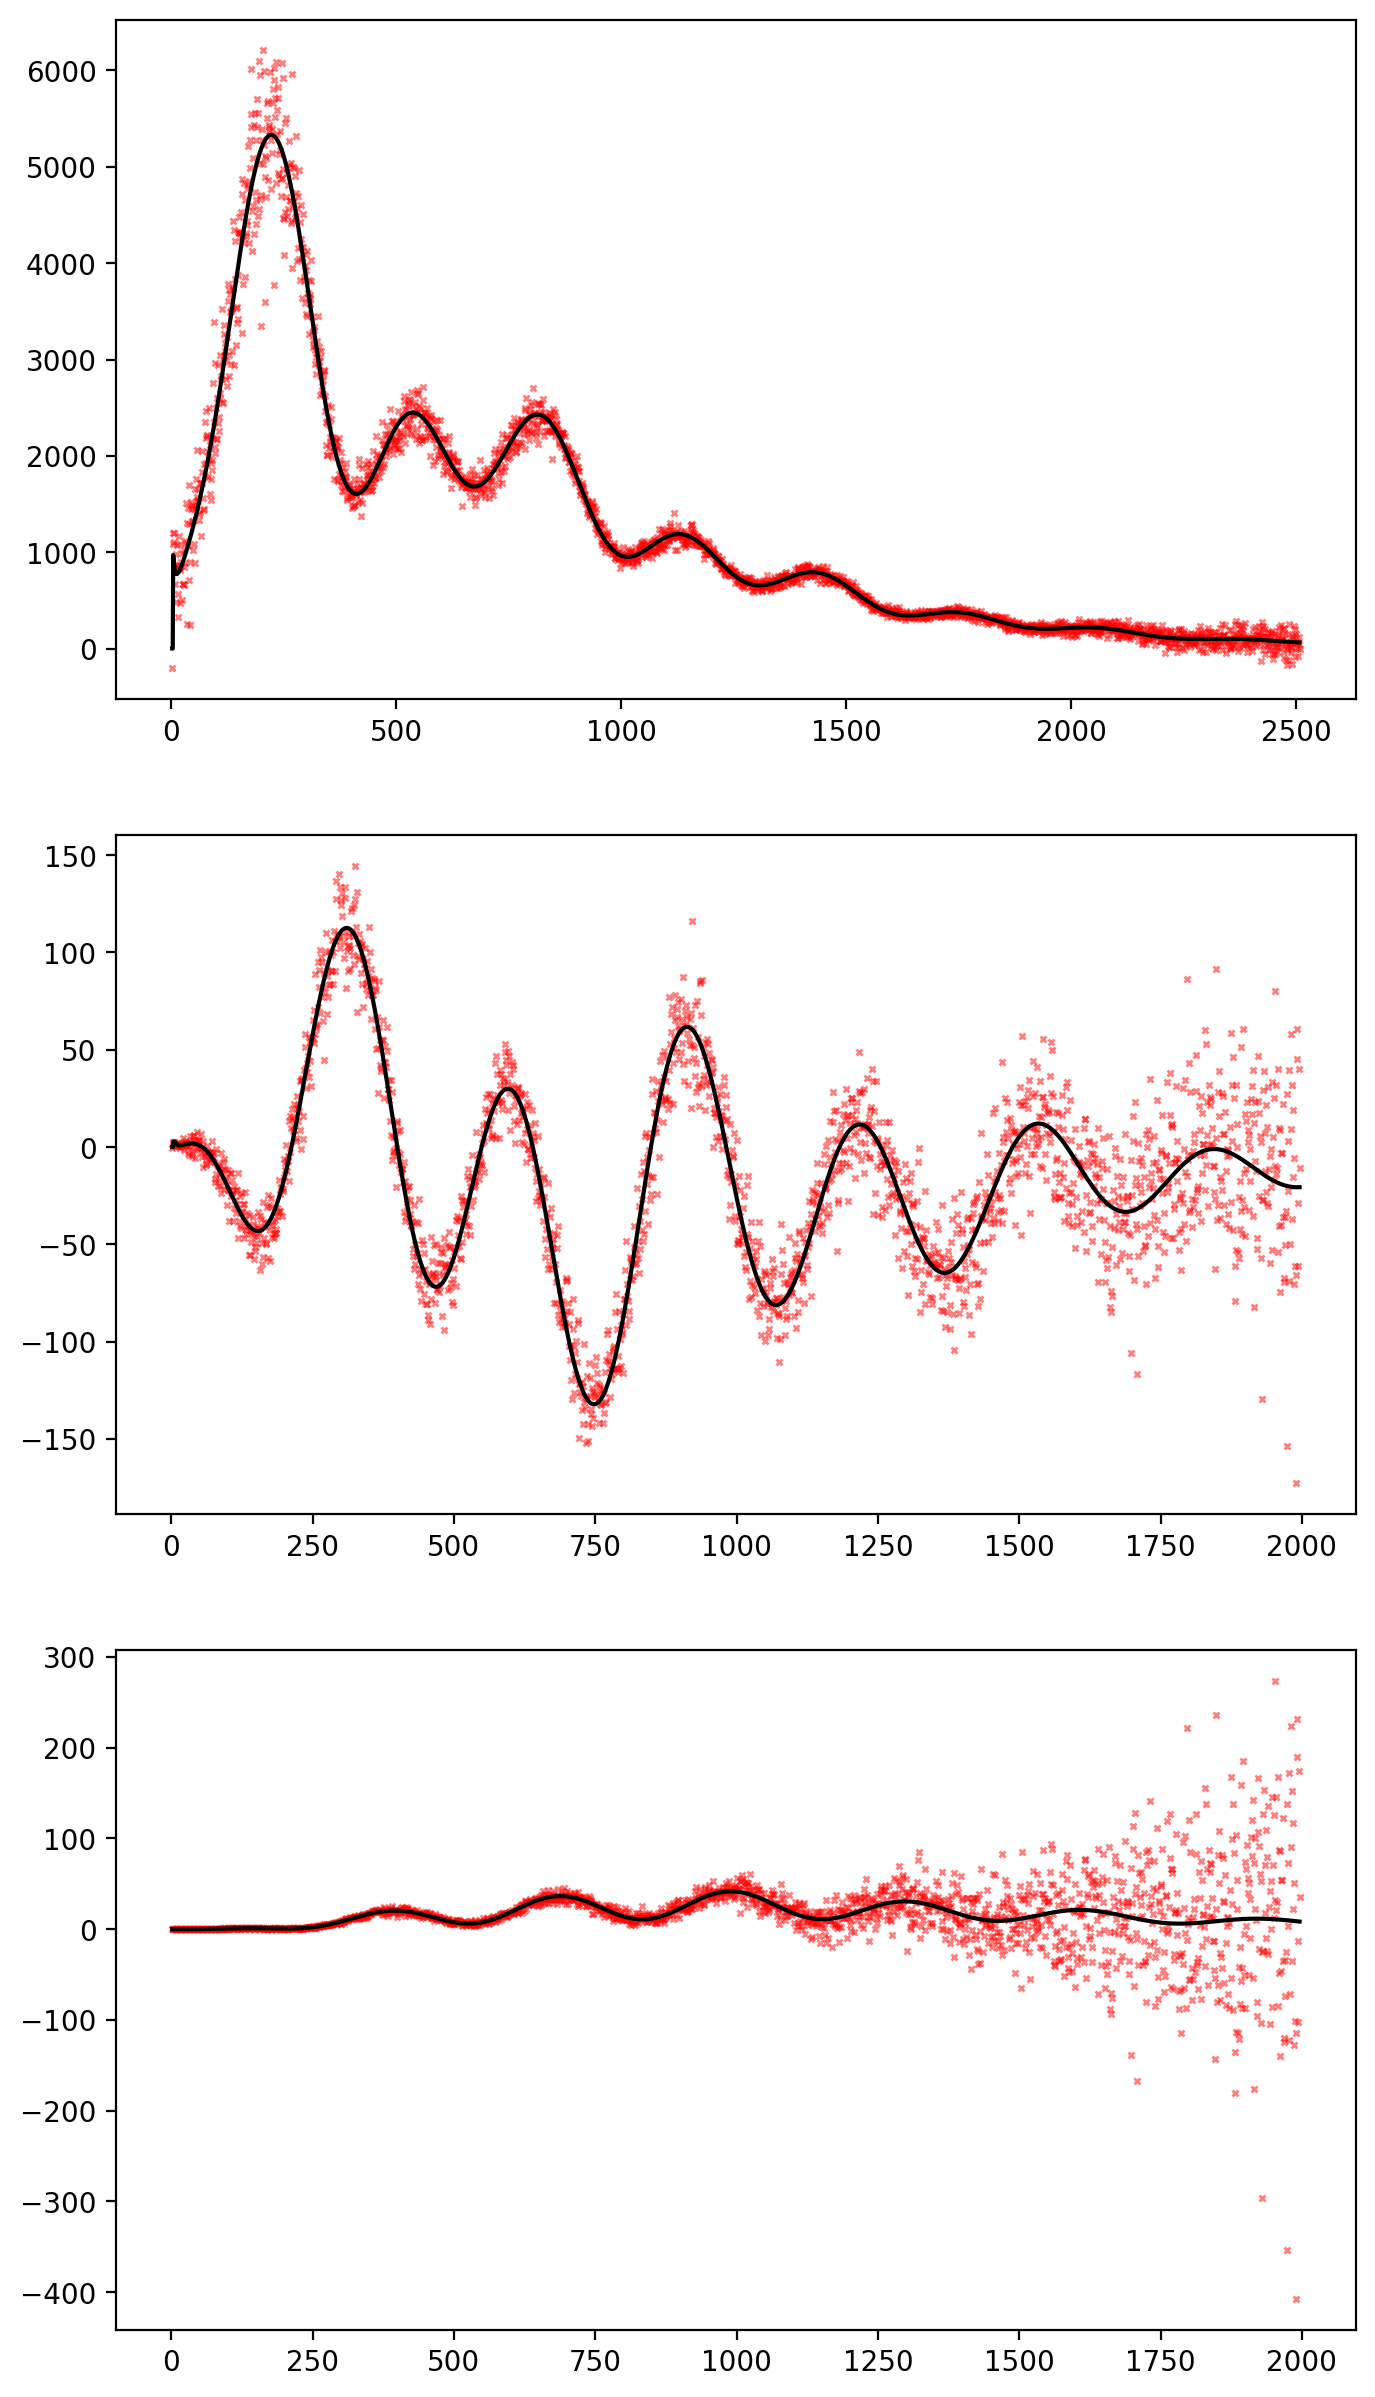

In [ ]:
fig, ax = plt.subplots(3,1, figsize = (8,15))
ax[0].plot(round_ls_Pl_TT,clstt_noisy[0], marker='x', color='red', label='Noisy', linestyle='None', markersize=2, alpha = 0.5)
ax[0].plot(round_ls_Pl_TT,clstt, color='black', label='$\Lambda CDM$', linestyle='-')
ax[1].plot(round_ls_Pl_TE,clste_noisy[0], marker='x', color='red', label='Noisy', linestyle='None', markersize=2, alpha = 0.5)
ax[1].plot(round_ls_Pl_TE,clste, color='black', label='$\Lambda CDM$', linestyle='-')
ax[2].plot(round_ls_Pl_EE,clsee_noisy[0], marker='x', color='red', label='Noisy', linestyle='None', markersize=2, alpha = 0.5)
ax[2].plot(round_ls_Pl_EE,clsee, color='black', label='$\Lambda CDM$', linestyle='-')
#Note: does camb output clste&clsee or dlste&dlsee?

(2551, 4)


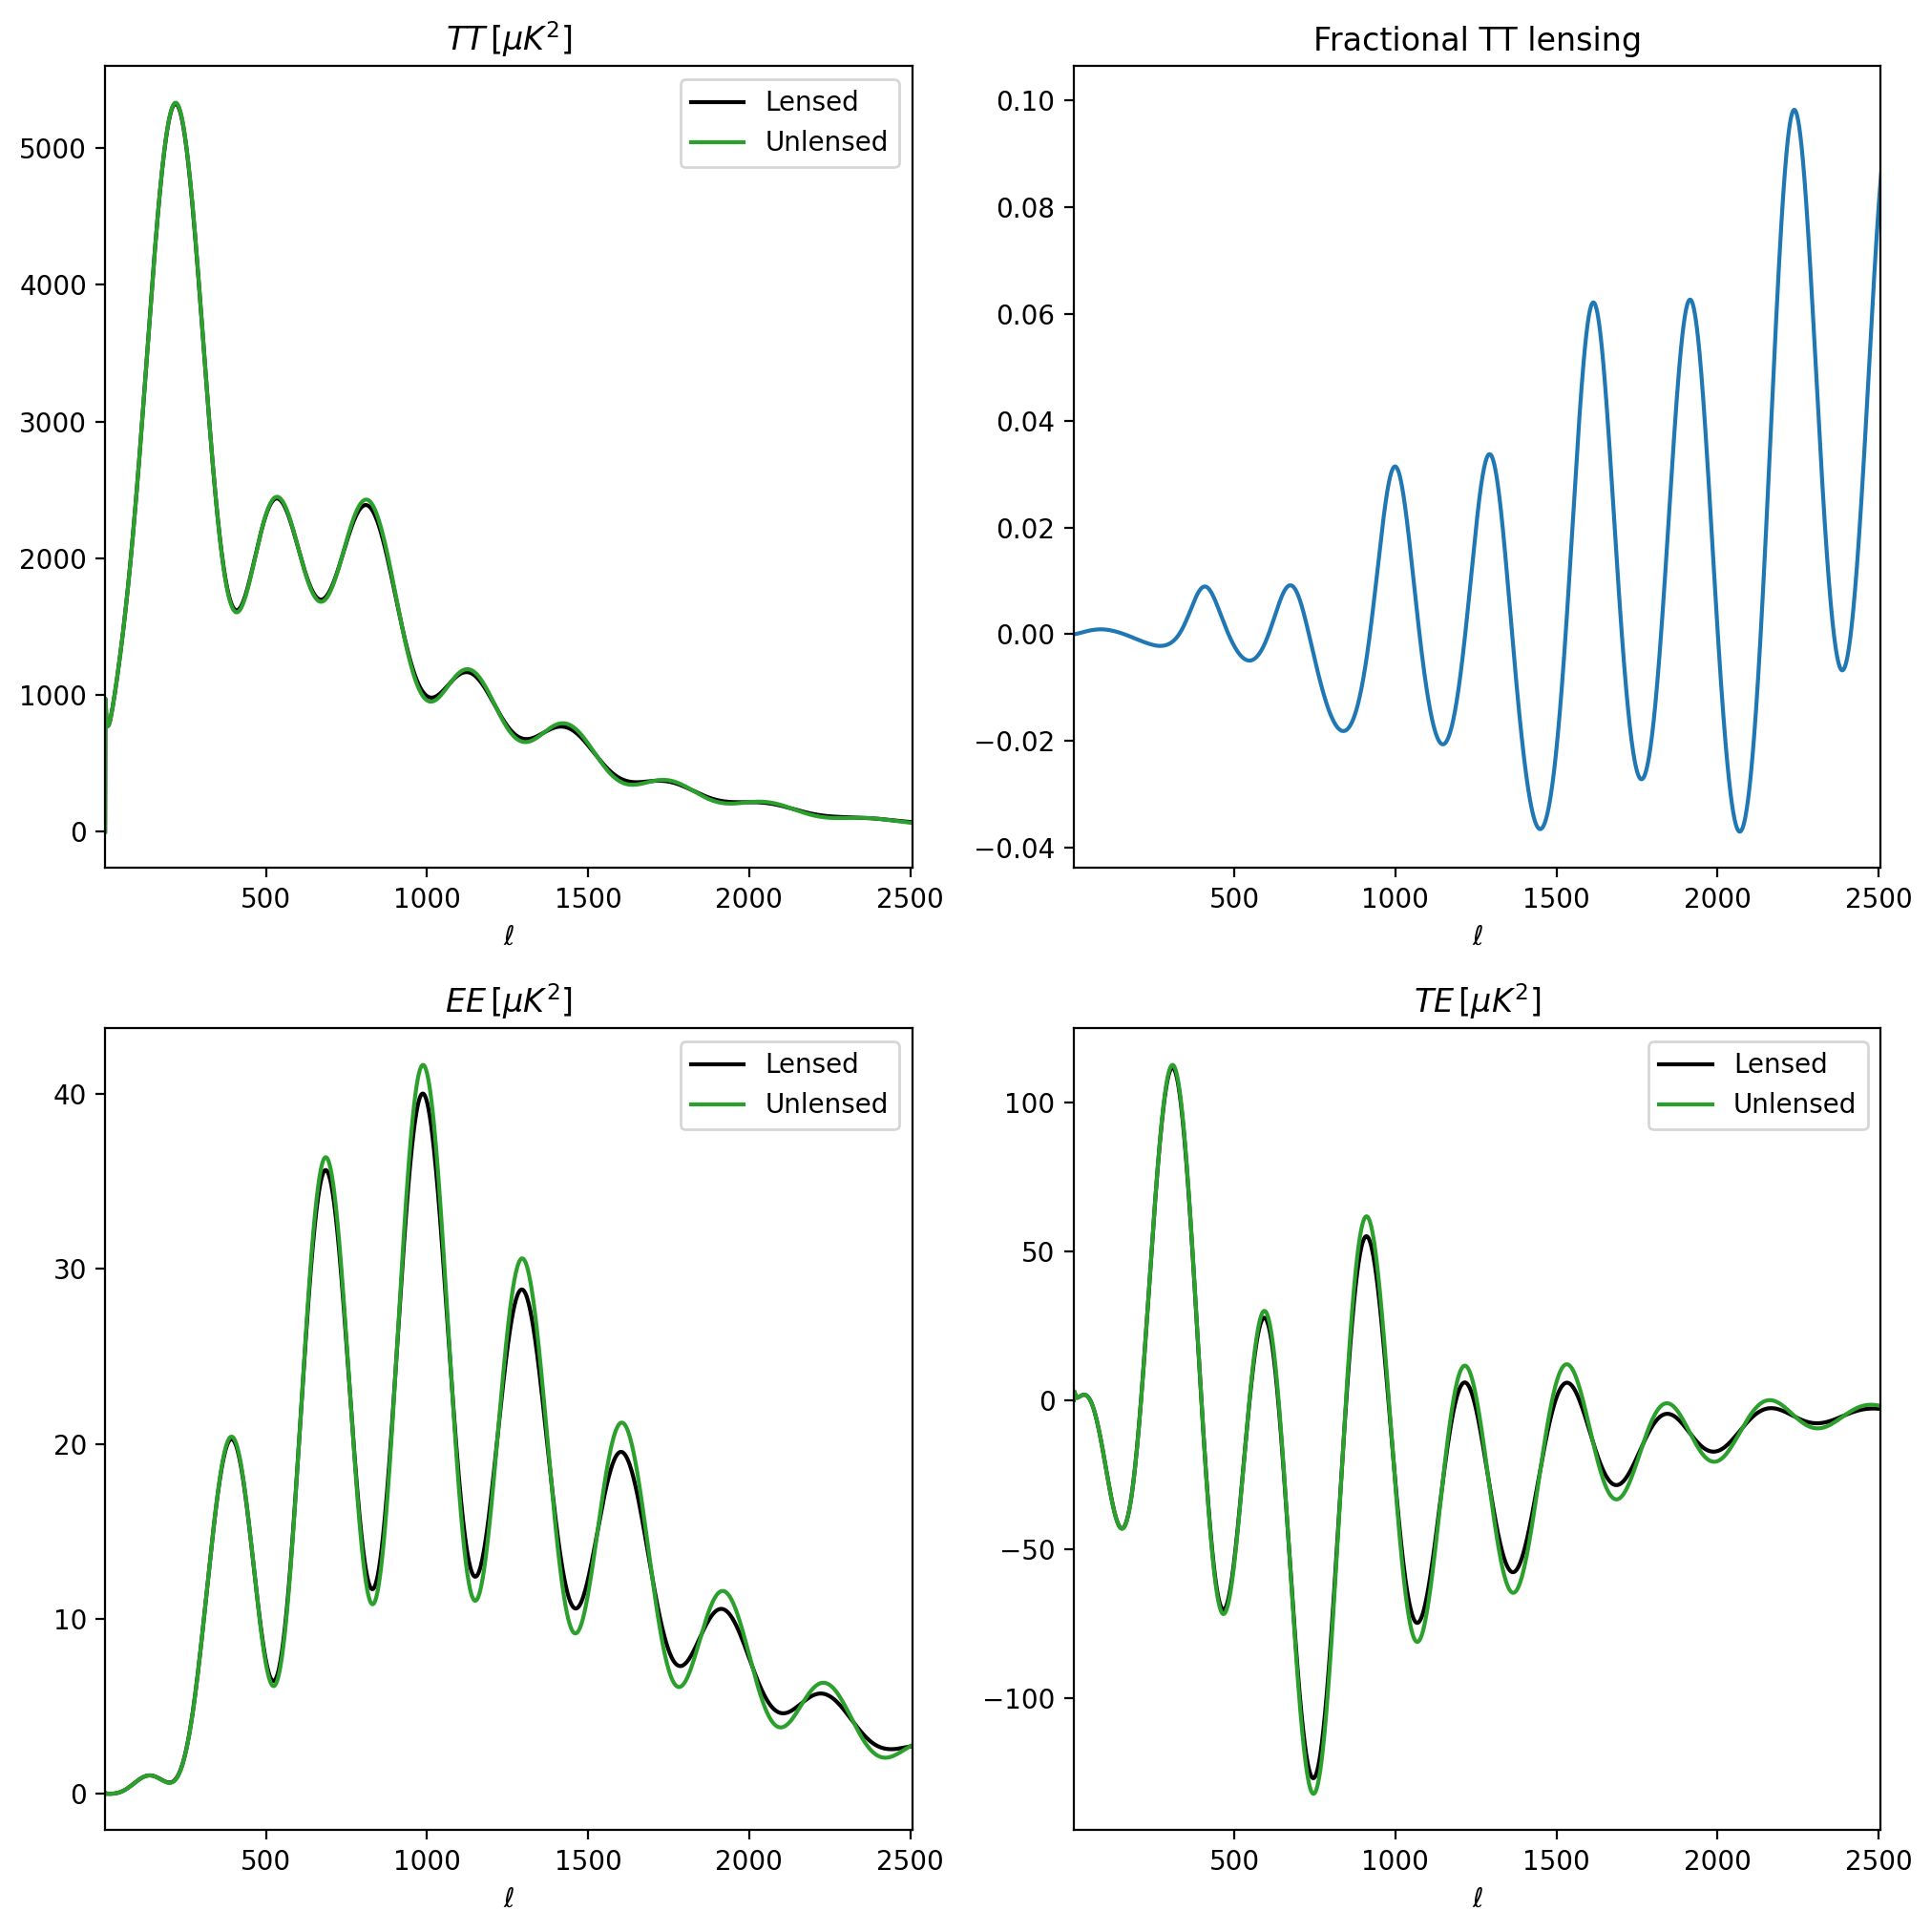

In [8]:
#plot the total lensed CMBa power spectra versus unlensed, and fractional difference
totCL=powers['total']
unlensedCL=powers['unlensed_scalar']
print(totCL.shape)
#Python CL arrays are all zero based (starting at L=0), Note L=0,1 entries will be zero by default.
#The different CL are always in the order TT, EE, BB, TE (with BB=0 for unlensed scalar results).
ls = np.arange(totCL.shape[0])
fig, ax = plt.subplots(2,2, figsize = (12,12))
ax[0,0].plot(ls,totCL[:,0], color='k', label='Lensed')
ax[0,0].plot(ls,unlensedCL[:,0], color='C2', label='Unlensed')
ax[0,0].set_title(r'$TT\, [\mu K^2]$')
ax[0,0].legend()
ax[0,1].plot(ls[2:], 1-unlensedCL[2:,0]/totCL[2:,0]);
ax[0,1].set_title(r'Fractional TT lensing')
ax[1,0].plot(ls,totCL[:,1], color='k', label='Lensed')
ax[1,0].plot(ls,unlensedCL[:,1], color='C2', label='Unlensed')
ax[1,0].set_title(r'$EE\, [\mu K^2]$')
ax[1,0].legend()
ax[1,1].plot(ls,totCL[:,3], color='k', label='Lensed')
ax[1,1].plot(ls,unlensedCL[:,3], color='C2', label='Unlensed')
ax[1,1].set_title(r'$TE\, [\mu K^2]$')
ax[1,1].legend()
for ax in ax.reshape(-1): 
    ax.set_xlim([2,2507])
    ax.set_xlabel(r'$\ell$');

In [10]:
#Let's look at some non-standard primordial power spectrum, e.g. with wavepacket oscillation

#Define our custom  power spectrum function (here power law with one wavepacket)
def PK(k, As, ns, amp, freq, wid, centre, phase):
    return As*(k/0.05)**(ns-1)*(1+ np.sin(phase+k*freq)*amp*np.exp(-(k-centre)**2/wid**2))

class: <CAMBparams>
 WantCls = True
 WantTransfer = False
 WantScalars = True
 WantTensors = False
 WantVectors = False
 WantDerivedParameters = True
 Want_cl_2D_array = True
 Want_CMB = True
 Want_CMB_lensing = True
 DoLensing = True
 NonLinear = NonLinear_none
 Transfer: <TransferParams>
   high_precision = False
   accurate_massive_neutrinos = False
   kmax = 0.9
   k_per_logint = 0
   PK_num_redshifts = 1
   PK_redshifts = [0.0]
 want_zstar = False
 want_zdrag = False
 min_l = 2
 max_l = 2657
 max_l_tensor = 600
 max_eta_k = 6642.5
 max_eta_k_tensor = 1200.0
 ombh2 = 0.022
 omch2 = 0.122
 omk = 0.0
 omnuh2 = 0.000644866570625114
 H0 = 67.5
 TCMB = 2.7255
 YHe = 0.24569492503497048
 num_nu_massless = 2.0293333333333337
 num_nu_massive = 1
 nu_mass_eigenstates = 1
 share_delta_neff = False
 nu_mass_degeneracies = [1.0146666666666666]
 nu_mass_fractions = [1.0]
 nu_mass_numbers = [1]
 InitPower: <SplinedInitialPower>
   effective_ns_for_nonlinear = 0.96
 Recomb: <Recfast>
   min_a_evo

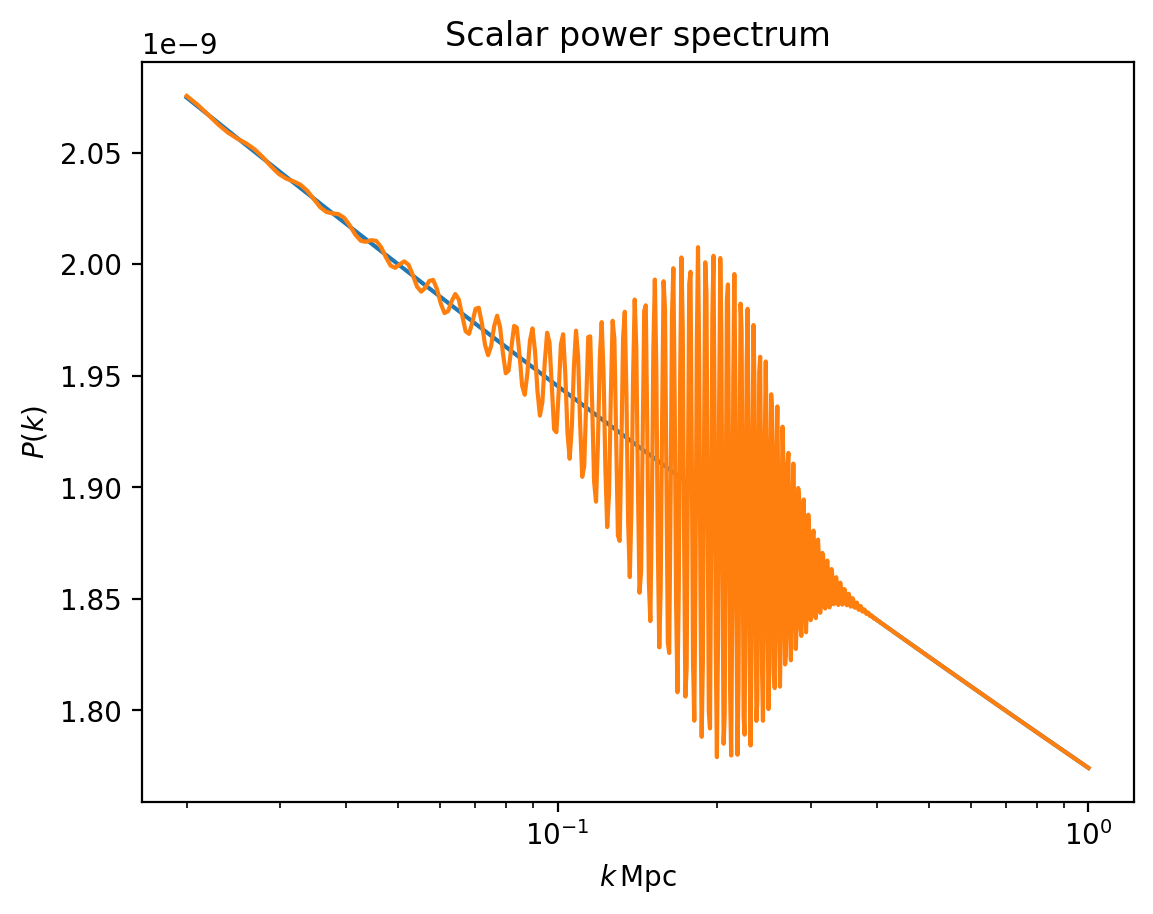

<Figure size 640x480 with 0 Axes>

In [11]:
freq = 1000
ks = np.linspace(0.02,1,1000)
pk1 = 2e-9*(ks/0.05)**(0.96-1)
pk2 = PK(ks,2e-9, 0.96,0.0599,freq, 0.08, 0.2,0)
plt.semilogx(ks,pk1)
plt.semilogx(ks,pk2)
plt.ylabel('$P(k)$')
plt.xlabel(r'$k\, {\rm Mpc}$');
plt.title('Scalar power spectrum')
plt.figure()

params.set_initial_power_function(PK, args=(2e-9, 0.96,0.0599, freq, 0.08, 0.2,0),
                               effective_ns_for_nonlinear=0.96)

In [ ]:
#Now compute C_l and compare
pars = camb.CAMBparams()
pars.set_cosmology(H0=67.5, ombh2=0.022, omch2=0.122, tau=0.06)
lmax=2507
pars.set_for_lmax(lmax,lens_potential_accuracy=1)

#For comparison, standard power law
pars.InitPower.set_params(As=2e-9, ns=0.96)
results = camb.get_results(pars)
cl_unlensed=results.get_unlensed_scalar_cls(CMB_unit ='muK')
cl=results.get_lensed_scalar_cls(CMB_unit ='muK')

#Note that if you have sharp features or fine oscillations, you may need 
#increase accuracy to sample them well. e.g. let's try increasing the frequency

#Default accuracy
pars.Accuracy.lSampleBoost = 1
pars.Accuracy.IntkAccuracyBoost =1
pars.Accuracy.SourcekAccuracyBoost =1

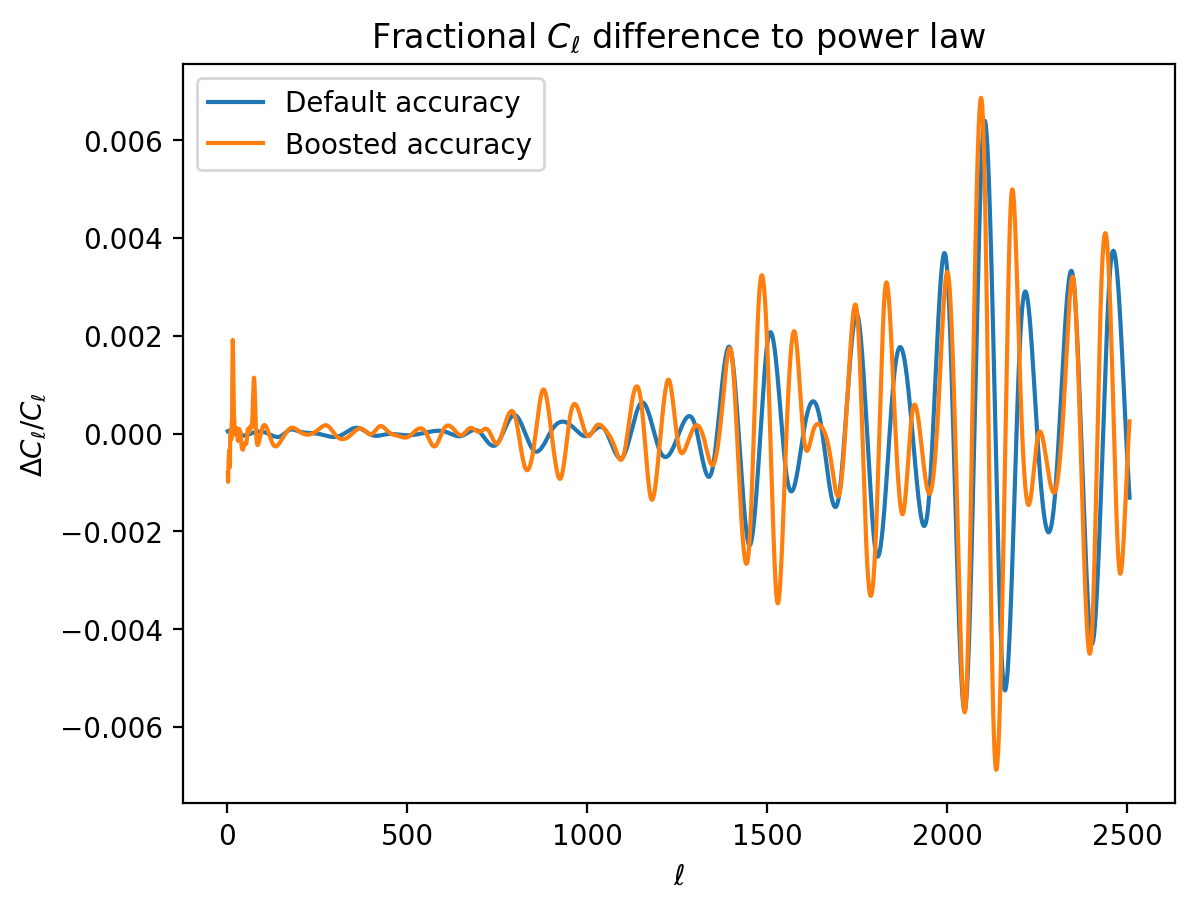

In [ ]:
results2 = camb.get_results(pars)
cl_unlensed2=results2.get_unlensed_scalar_cls(CMB_unit ='muK')

#need to increase default sampling in ell to see features smaller than peaks reliably
pars.Accuracy.lSampleBoost = 2
#may also need to sample k more densely when computing C_l from P(k)
pars.Accuracy.IntkAccuracyBoost = 2 

results3 = camb.get_results(pars)
cl_unlensed3=results3.get_unlensed_scalar_cls(CMB_unit ='muK')
cl3=results3.get_lensed_scalar_cls(CMB_unit ='muK')

ls = np.arange(2,lmax)
plt.plot(ls,(cl_unlensed2[2:lmax,0]/cl_unlensed[2:lmax,0]-1))
plt.plot(ls,(cl_unlensed3[2:lmax,0]/cl_unlensed[2:lmax,0]-1))

plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell/C_\ell$')
plt.title(r'Fractional $C_\ell$ difference to power law')
plt.legend(['Default accuracy','Boosted accuracy']);

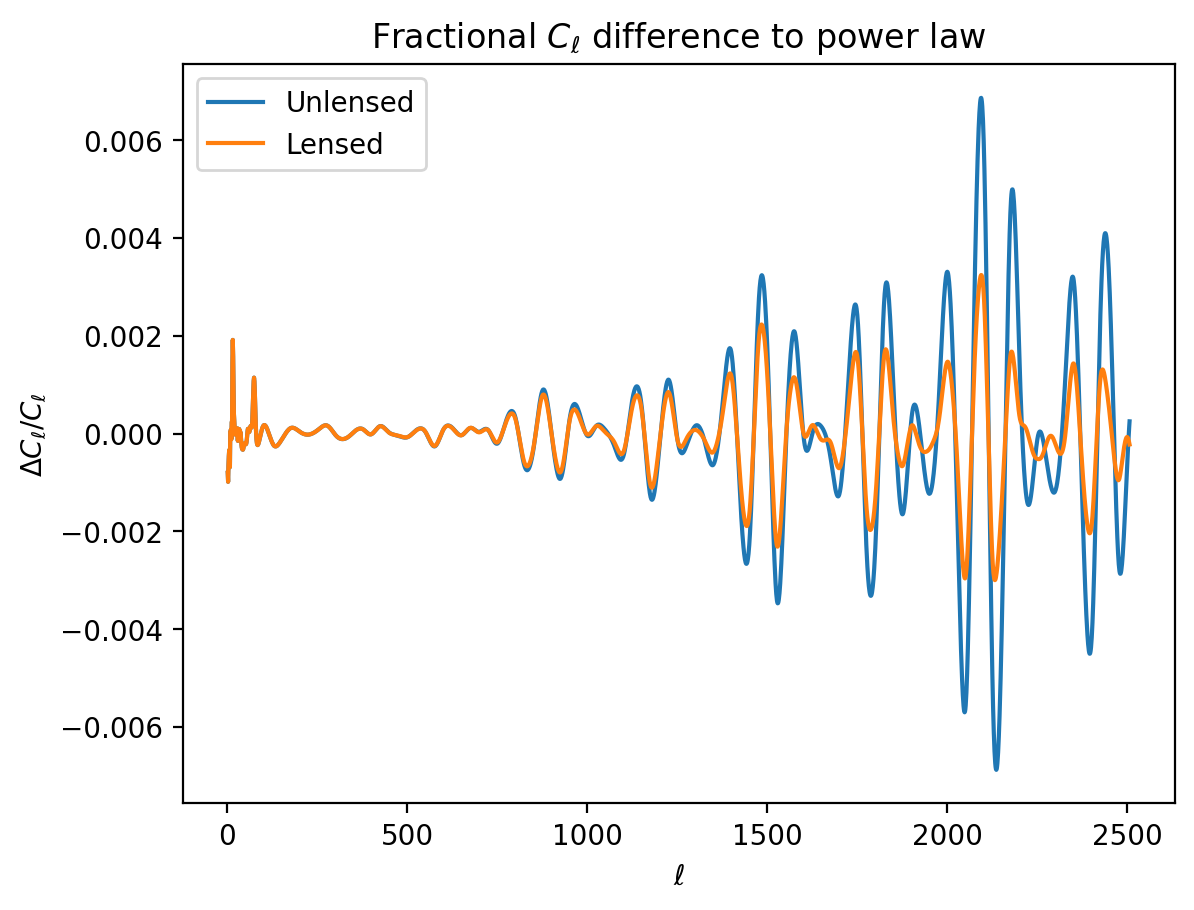

In [ ]:
#Note that lensing washes out small features on small scales
plt.plot(ls,(cl_unlensed3[2:lmax,0]/cl_unlensed[2:lmax,0]-1))
plt.plot(ls,(cl3[2:lmax,0]/cl[2:lmax,0]-1))
plt.xlabel(r'$\ell$')
plt.ylabel(r'$\Delta C_\ell/C_\ell$')
plt.legend(['Unlensed','Lensed'])
plt.title(r'Fractional $C_\ell$ difference to power law');